In [80]:
import pandas as pd
import numpy as np

https://kuraisle.github.io/jmw/data-analysis/gdsc_drug_models.html

Exp's Data.ID is Data.COSMIC ID

Expression is from here.
This is log2 RPKM+1. We need to have log(TPM+1)  
https://discover.nci.nih.gov/cellminercdb/

In [81]:
# exp = pd.read_csv("/Users/inouey2/Downloads/Cell_line_RMA_proc_basalExp.txt", sep="\t")
# exp = exp.dropna()
# exp.index = list(exp["GENE_SYMBOLS"])
# exp = exp.drop(["GENE_SYMBOLS", "GENE_title"], axis=1)
# exp = exp.sort_index()
# exp = exp.T
# exp.index = [i[5:] for i in exp.index]

In [82]:
exp = pd.read_csv('/Users/inouey2/Downloads/data_GDSC-MGH-Sanger_xsq.zip', sep='\t').T
exp.columns = list(exp.loc['ensembl_gene_id'])
exp = exp.iloc[6:]
exp = exp.dropna()
exp.shape

/var/folders/y3/ssnk1ytd3m5bjmrchh2lt74srg76p8/T/ipykernel_95789/2097962208.py:1: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  exp = pd.read_csv('/Users/inouey2/Downloads/data_GDSC-MGH-Sanger_xsq.zip', sep='\t').T


(442, 37263)

In [83]:
exp

,ENSG00000121410,ENSG00000268895,ENSG00000148584,ENSG00000175899,ENSG00000245105,ENSG00000166535,ENSG00000256661,ENSG00000256904,ENSG00000256069,ENSG00000184389,...,ENSG00000203995,ENSG00000232242,ENSG00000162378,ENSG00000159840,ENSG00000274572,ENSG00000074755,ENSG00000036549,ENSG00000167524,ENSG00000253251,ENSG00000272899
451Lu,0.250962,2.375735,0.0,6.451211,0.124328,0.014355,0.0,0.0,0.0,0.124328,...,0.028569,0.176323,3.217231,5.683977,0.0,2.752749,2.675816,1.232661,1.182692,1.163499
A388,0.124328,0.028569,0.0,0.0,0.070389,2.140779,0.0,0.0,0.014355,0.014355,...,0.070389,0.0,2.763412,5.759422,0.0,4.070389,3.327687,3.680324,1.70044,0.378512
A427,0.356144,1.356144,0.0,0.014355,2.967169,0.0,0.042644,0.014355,0.0,0.014355,...,2.192194,0.0,2.400538,5.439623,0.0,1.819668,2.488001,1.356144,2.15056,0.545968
A431,0.111031,0.963474,0.0,0.0,0.163499,0.097611,0.0,0.042644,0.0,0.124328,...,0.214125,0.0,4.0,6.068886,0.0,2.344828,4.103498,2.545968,1.286881,0.516015
ACN,0.321928,2.232661,0.0,5.068671,0.137504,0.014355,0.042644,0.0,0.0,0.15056,...,0.263034,0.505891,4.219556,5.144046,0.0,2.084064,3.534809,2.568032,1.298658,0.604071
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZR-75-30,0.226509,2.286881,0.0,0.137504,0.367371,0.389567,0.056584,0.0,0.028569,0.014355,...,1.823749,0.0,2.857981,4.372256,0.0,1.937344,2.788686,4.277241,0.887525,0.070389
SNU-283,0.056584,0.014355,1.871844,0.0,0.286881,0.014355,0.0,0.028569,0.0,0.15056,...,0.028569,0.0,2.104337,4.536675,0.0,3.914565,2.707083,1.744161,1.505891,0.85599
BONNA-12,0.084064,1.263034,0.0,0.056584,0.0,0.014355,0.0,0.0,0.0,0.028569,...,0.722466,0.0,1.618239,4.614121,0.0,2.330558,2.405992,1.157044,1.918386,0.214125
NCI-H740,0.485427,2.121015,0.0,0.028569,0.378512,0.014355,0.070389,0.014355,0.0,0.536053,...,1.641546,0.0,4.086614,3.047887,0.0,2.111031,4.077243,1.978196,2.292782,0.790772


In [85]:
RPKM = np.power(2.0, exp.astype("float64")) - 1.0
TPM = RPKM.div(RPKM.sum(axis=1), axis=0) * 1e6
logTPM_values = np.log1p(TPM.to_numpy(dtype="float64"))
logTPM = pd.DataFrame(logTPM_values, index=TPM.index, columns=TPM.columns)

In [88]:
logTPM.to_csv("dataset/gdsc/exp.csv.gz", compression="gzip")

In [89]:
ls

__pycache__/           preprocess_GDSC.ipynb  Untitled.ipynb
dataset/               preprocess_TCGA.ipynb


In [90]:
pwd

'/Users/inouey2/code/vec2vec/prep'

In [68]:
df = pd.read_excel(
    "/Users/inouey2/Downloads/GDSC1_fitted_dose_response_27Oct23.xlsx",
    usecols=[
        "COSMIC_ID",
        "CELL_LINE_NAME",
        "DRUG_NAME",
        "DRUG_ID",
        "PUTATIVE_TARGET",
        "PATHWAY_NAME",
        "LN_IC50",
        "AUC",
    ],
)
df["COSMIC_ID"] = df["COSMIC_ID"].astype(str)
df

,COSMIC_ID,CELL_LINE_NAME,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,LN_IC50,AUC
0,684057,ES5,1,Erlotinib,EGFR,EGFR signaling,3.966813,0.985678
1,684059,ES7,1,Erlotinib,EGFR,EGFR signaling,2.692090,0.972690
2,684062,EW-11,1,Erlotinib,EGFR,EGFR signaling,2.477990,0.944459
3,684072,SK-ES-1,1,Erlotinib,EGFR,EGFR signaling,2.033564,0.950758
4,687448,COLO-829,1,Erlotinib,EGFR,EGFR signaling,2.966007,0.954778
...,...,...,...,...,...,...,...,...
333156,1659823,SNU-1040,1531,I-CBP112,"EP300, CBP",Chromatin histone acetylation,5.085294,0.972251
333157,1660035,SNU-61,1531,I-CBP112,"EP300, CBP",Chromatin histone acetylation,5.725399,0.976109
333158,1660036,SNU-81,1531,I-CBP112,"EP300, CBP",Chromatin histone acetylation,4.930753,0.970851
333159,1674021,SNU-C5,1531,I-CBP112,"EP300, CBP",Chromatin histone acetylation,4.551784,0.972330


In [69]:
len(df["COSMIC_ID"].unique())

970

In [70]:
len(exp.index)

442

In [71]:
coexist = list(set(exp.index) & set(df["CELL_LINE_NAME"]))
len(coexist)

392

In [72]:
df = df[df.CELL_LINE_NAME.isin(coexist)]
df.head()

,COSMIC_ID,CELL_LINE_NAME,DRUG_ID,DRUG_NAME,PUTATIVE_TARGET,PATHWAY_NAME,LN_IC50,AUC
0,684057,ES5,1,Erlotinib,EGFR,EGFR signaling,3.966813,0.985678
1,684059,ES7,1,Erlotinib,EGFR,EGFR signaling,2.692090,0.972690
2,684062,EW-11,1,Erlotinib,EGFR,EGFR signaling,2.477990,0.944459
8,687600,NCI-H720,1,Erlotinib,EGFR,EGFR signaling,3.694213,0.986085
11,687804,NCI-H1770,1,Erlotinib,EGFR,EGFR signaling,3.259282,0.988218


(134859, 8)

In [73]:
exp = exp[exp.index.isin(coexist)].sort_index()
exp

,ENSG00000121410,ENSG00000268895,ENSG00000148584,ENSG00000175899,ENSG00000245105,ENSG00000166535,ENSG00000256661,ENSG00000256904,ENSG00000256069,ENSG00000184389,...,ENSG00000203995,ENSG00000232242,ENSG00000162378,ENSG00000159840,ENSG00000274572,ENSG00000074755,ENSG00000036549,ENSG00000167524,ENSG00000253251,ENSG00000272899
451Lu,0.250962,2.375735,0.0,6.451211,0.124328,0.014355,0.0,0.0,0.0,0.124328,...,0.028569,0.176323,3.217231,5.683977,0.0,2.752749,2.675816,1.232661,1.182692,1.163499
A388,0.124328,0.028569,0.0,0.0,0.070389,2.140779,0.0,0.0,0.014355,0.014355,...,0.070389,0.0,2.763412,5.759422,0.0,4.070389,3.327687,3.680324,1.70044,0.378512
A427,0.356144,1.356144,0.0,0.014355,2.967169,0.0,0.042644,0.014355,0.0,0.014355,...,2.192194,0.0,2.400538,5.439623,0.0,1.819668,2.488001,1.356144,2.15056,0.545968
A431,0.111031,0.963474,0.0,0.0,0.163499,0.097611,0.0,0.042644,0.0,0.124328,...,0.214125,0.0,4.0,6.068886,0.0,2.344828,4.103498,2.545968,1.286881,0.516015
ALL-PO,0.799087,3.025029,0.0,0.226509,0.028569,0.014355,0.028569,0.111031,0.0,0.111031,...,0.042644,0.0,3.420887,4.84549,0.0,3.139142,3.521051,3.327687,1.111031,1.344828
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
YH-13,0.422233,2.427606,0.0,0.163499,0.124328,0.0,0.0,0.0,0.0,0.321928,...,0.0,0.0,3.042644,8.020147,0.0,1.948601,2.78031,2.014355,0.918386,0.871844
YT,0.056584,0.014355,0.0,0.014355,0.042644,0.0,0.0,0.137504,0.0,0.0,...,0.084064,0.214125,3.090853,6.392146,0.0,3.168321,2.516015,3.122673,1.929791,0.739848
ZR-75-30,0.226509,2.286881,0.0,0.137504,0.367371,0.389567,0.056584,0.0,0.028569,0.014355,...,1.823749,0.0,2.857981,4.372256,0.0,1.937344,2.788686,4.277241,0.887525,0.070389
no-10,0.333424,1.02148,0.0,0.028569,0.0,0.0,0.0,0.042644,0.014355,0.097611,...,0.042644,0.014355,3.255501,5.674404,0.0,2.130931,3.581351,2.304511,1.718088,0.176323


# IC50

<Axes: >

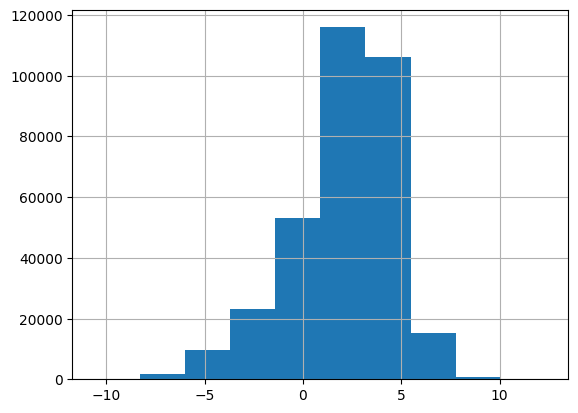

In [15]:
df["LN_IC50"].hist()

<Axes: >

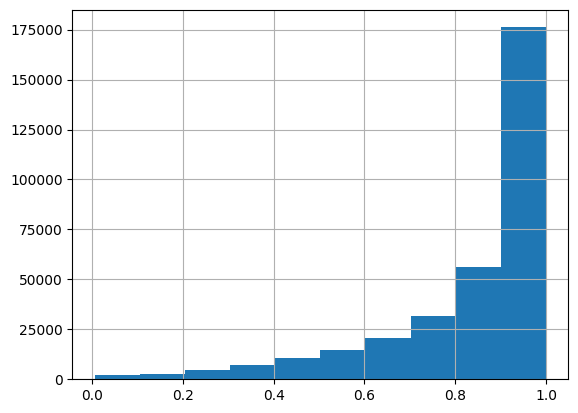

In [16]:
df["AUC"].hist()

# AUC is biased and LN_IC50 is following normal distribution, so chose LN_IC50

## Next Steps

- **Standardize LN_IC50 per drug (z-score)** to remove scale and mean differences.  
- **Use LN_IC50 as the main regression target** with MSE or Huber loss.  
- **Ensure direction consistency**: higher sensitivity = lower LN_IC50.  
- **Evaluate per drug** using RMSE/MAE (z-score) and Spearman correlation (ranking).  

In [17]:
r = (
    pd.read_csv("../Aug8_nsc_cid_smiles.csv", index_col=0)[["NAME", "SMILES"]]
    .dropna()
    .drop_duplicates()
)

In [18]:
drugs = df["DRUG_NAME"].unique()
len(drugs)

378

In [19]:
tmp = r[r["NAME"].isin(drugs)]

In [20]:
k = pd.read_csv(
    "/Users/inouey2/Downloads/2775739846192591652.txt.gz", sep="\t", header=None
).dropna()
k.columns = tmp.columns

In [21]:
hand = [
    ["A-484954", "CCN1C(=O)C2=CC(=C(N=C2N(C1=O)C3CC3)N)C(=O)N"],
    ["JQ12", "O=C(NC1=CC(C2=CC=CS2)=CC=C1N)C3=CC=C(NC(C)=O)C=C3"],
    [
        "HG-6-71-01",
        "COC(=C1CNC(=CC(NC(C(=CC=C(C2C(F)(F)F)CN(CCN3CC)CC3)C=2)=O)=CC2)C=2C)C(=C(N=C1)N1)C=C1",
    ],
    [
        "MPS-1-IN-1",
        "O=S(C(C=CC=C1)=C1NC2=CC(NC3=C(OC)C=C(N4CCC(O)CC4)C=C3)=NC5=C2C=CN5)(C(C)C)=O",
    ],
    [
        "THZ-1-87",
        "CN(C)CC=CC(=O)NC1=CC=C(C=C1)C(=O)NC2=CC=CC(=C2)NC3=NC=C(C(=N3)C4=CNC5=CC=CC=C54)Cl",
    ],
    ["JNK-9L", "Fc1cc(cc(c1)c1ccnc(n1)Nc1ccc(cc1)n1cnc(n1)N1CCOCC1)N1CCOCC1"],
]
hand = pd.DataFrame(hand, columns=tmp.columns)

In [22]:
tmp = pd.concat([tmp, k, hand]).drop_duplicates()
tmp

,NAME,SMILES
11,Methotrexate,CN(CC1=CN=C2C(=N1)C(=NC(=N2)N)N)C3=CC=C(C=C3)C...
67,Pyrimethamine,CCC1=C(C(=NC(=N1)N)N)C2=CC=C(C=C2)Cl
472,5-Fluorouracil,C1=C(C(=O)NC(=O)N1)F
585,Mitomycin-C,CC1=C(C(=O)C2=C(C1=O)N3CC4C(C3(C2COC(=O)N)OC)N4)N
983,Vinblastine,CCC1(CC2CC(C3=C(CCN(C2)C1)C4=CC=CC=C4N3)(C5=C(...
...,...,...
1,JQ12,O=C(NC1=CC(C2=CC=CS2)=CC=C1N)C3=CC=C(NC(C)=O)C=C3
2,HG-6-71-01,COC(=C1CNC(=CC(NC(C(=CC=C(C2C(F)(F)F)CN(CCN3CC...
3,MPS-1-IN-1,O=S(C(C=CC=C1)=C1NC2=CC(NC3=C(OC)C=C(N4CCC(O)C...
4,THZ-1-87,CN(C)CC=CC(=O)NC1=CC=C(C=C1)C(=O)NC2=CC=CC(=C2...


In [23]:
merged = df.merge(tmp, left_on="DRUG_NAME", right_on="NAME", how="inner")
merged = merged[["COSMIC_ID", "NAME", "LN_IC50", "SMILES"]]
merged.head()

,COSMIC_ID,NAME,LN_IC50,SMILES
0,684057,Erlotinib,3.966813,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...
1,684059,Erlotinib,2.692090,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...
2,684062,Erlotinib,2.477990,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...
3,684072,Erlotinib,2.033564,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...
4,687448,Erlotinib,2.966007,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...


In [24]:
merged["Z_score"] = merged.groupby("NAME")["LN_IC50"].transform(
    lambda x: (x - x.mean()) / x.std(ddof=0) if x.std(ddof=0) > 0 else 0
)
merged.head()

,COSMIC_ID,NAME,LN_IC50,SMILES,Z_score
0,684057,Erlotinib,3.966813,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,1.305495
1,684059,Erlotinib,2.692090,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,0.166286
2,684062,Erlotinib,2.477990,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,-0.025053
3,684072,Erlotinib,2.033564,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,-0.422233
4,687448,Erlotinib,2.966007,COCCOC1=C(C=C2C(=C1)C(=NC=N2)NC3=CC=CC(=C3)C#C...,0.411083


In [25]:
merged.to_csv("dataset/gdsc/cellline_info.csv.gz", compression="gzip")